# 🛡️ UrbanShield: AI-Driven Flood Prediction Pipeline

Notebook ini berisi alur lengkap *Machine Learning* untuk proyek **UrbanShield**, mulai dari pemrosesan data, analisis visual, hingga pelatihan model prediksi banjir untuk dua skenario utama:
1. **Nowcasting**: Memprediksi kondisi banjir saat ini (0 jam).
2. **Forecasting**: Memprediksi potensi banjir dalam horizon waktu +3 jam, +6 jam, dan +12 jam ke depan.

---

## 🛠️ Chapter 2: Environment Setup
Pada tahap ini, kita memuat semua *library* yang dibutuhkan, mengatur konfigurasi visualisasi, dan menyiapkan folder untuk menyimpan hasil evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

DATA_PATH   = 'UrbanShield_ABT_Final.csv'   
OUTPUT_DIR  = './'                          
VISUAL_DIR  = './visuals/'                  
RANDOM_SEED = 42
HORIZONS    = [3, 6, 12]                  

# Buat folder visuals jika belum ada
if not os.path.exists(VISUAL_DIR):
    os.makedirs(VISUAL_DIR)

# Tema Warna
COLORS = {
    'primary':   '#1E3A5F',
    'secondary': '#2E86AB',
    'accent':    '#F18F01',
    'danger':    '#C73E1D',
    'success':   '#3BB273',
    'light':     '#F4F6F9',
    'mid':       '#8BA3BC',
}
HORIZON_COLORS = {
    3:  COLORS['success'],
    6:  COLORS['secondary'],
    12: COLORS['accent'],
}

plt.rcParams.update({
    'figure.facecolor':  COLORS['light'],
    'axes.facecolor':    COLORS['light'],
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

## 📥 Chapter 3: Data Loading & Initial Inspection
Memuat dataset hasil *preprocessing* (`UrbanShield_ABT_Final.csv`) dan memeriksa distribusi target banjir.

In [2]:
print("  STEP 1 — LOAD DATA")
df = pd.read_csv(DATA_PATH)
print(f"  Shape   : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Kolom   : {list(df.columns)}")

vc = df['status_banjir'].value_counts()
print(f"\n  Target distribution:")
for v, c in vc.items():
    label = 'Banjir' if v else 'Normal'
    bar   = '█' * int(c / len(df) * 40)
    print(f"    {label:6s}: {c:,} ({c/len(df)*100:.1f}%) {bar}")

  STEP 1 — LOAD DATA
  Shape   : 131,450 baris × 16 kolom
  Kolom   : ['datetime', 'tanggal', 'jam', 'kota_administrasi', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'soil_temperature_0_to_7cm', 'precipitation', 'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum', 'status_banjir']

  Target distribution:
    Normal: 120,866 (91.9%) ████████████████████████████████████
    Banjir: 10,584 (8.1%) ███


## ⚙️ Chapter 4: Base Preprocessing
Mengonversi tipe data *datetime*, mengurutkan data berdasarkan waktu, dan melakukan pengodean kategori untuk wilayah kota.

In [3]:
print("  STEP 2 — PREPROCESSING")

df['datetime'] = pd.to_datetime(df['datetime'])
df['tanggal']  = pd.to_datetime(df['tanggal'])
df = df.sort_values(['kota_administrasi', 'datetime']).reset_index(drop=True)

df['hour']        = df['datetime'].dt.hour
df['month']       = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['day_of_year'] = df['datetime'].dt.dayofyear
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

df['musim'] = df['month'].apply(lambda m: 1 if m in [11, 12, 1, 2, 3, 4] else 0)

le = LabelEncoder()
df['kota_encoded'] = le.fit_transform(df['kota_administrasi'])
print(f"  Kota mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f"  ✓ Datetime parsed, sorted per kota")
print(f"  ✓ Time features extracted")
print(f"  ✓ Kota encoded")

  STEP 2 — PREPROCESSING
  Kota mapping: {'jakarta barat': 0, 'jakarta pusat': 1, 'jakarta selatan': 2, 'jakarta timur': 3, 'jakarta utara': 4}
  ✓ Datetime parsed, sorted per kota
  ✓ Time features extracted
  ✓ Kota encoded


## 🛠️ Chapter 5: Feature Engineering (Step 3)
Membuat fitur-fitur baru yang lebih kompleks seperti `rain_score`, indeks saturasi, dan intensitas hujan. 
**Note:** Di akhir tahap ini, dataset yang sudah di-*engineered* akan disimpan sebagai `UrbanShield_Base_Engineered.csv`.

In [4]:
print("  STEP 3 — FEATURE ENGINEERING (Nowcasting)")

df['precip_ratio_3_12']  = df['precip_3h_sum']  / (df['precip_12h_sum'] + 0.001)
df['precip_ratio_6_12']  = df['precip_6h_sum']  / (df['precip_12h_sum'] + 0.001)
df['precip_intensity']   = df['precipitation']  / (df['precip_3h_sum']  + 0.001)

df['rain_score'] = (
    df['precipitation']  * 0.4 +
    df['precip_3h_sum']  * 0.3 +
    df['precip_6h_sum']  * 0.2 +
    df['precip_12h_sum'] * 0.1
)

df['saturation_idx'] = df['relative_humidity_2m'] * df['precipitation'] / 100
df['heat_index']     = df['temperature_2m'] * df['relative_humidity_2m'] / 100
df['wind_energy']    = df['wind_speed_10m'] ** 2
df['is_raining']     = (df['precipitation'] > 0).astype(int)
df['heavy_rain']     = (df['precipitation'] > df['precipitation'].quantile(0.90)).astype(int)

FEATURE_COLS_NOW = [
    'temperature_2m', 'relative_humidity_2m', 'surface_pressure',
    'wind_speed_10m', 'wind_direction_10m', 'weather_code',
    'soil_temperature_0_to_7cm', 'precipitation',
    'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum',
    'kota_encoded', 'hour', 'month', 'day_of_week', 'musim', 'is_weekend',
    'precip_ratio_3_12', 'precip_ratio_6_12', 'precip_intensity',
    'rain_score', 'saturation_idx', 'heat_index',
    'wind_energy', 'is_raining', 'heavy_rain',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
]

print(f"  ✓ {len(FEATURE_COLS_NOW)} fitur siap")

# Simpan file UrbanShield_Base_Engineered.csv
output_csv = 'UrbanShield_Base_Engineered.csv'
df.to_csv(output_csv, index=False)
print(f"  ✓ File disimpan: {output_csv}")

  STEP 3 — FEATURE ENGINEERING (Nowcasting)
  ✓ 30 fitur siap
  ✓ File disimpan: UrbanShield_Base_Engineered.csv


## 📊 Chapter 6: Exploratory Data Analysis (EDA - Step 4)
Melakukan visualisasi mendalam (Distribusi target, pola per jam, dan korelasi fitur) menggunakan fitur-fitur yang baru saja dibuat.

  STEP 4 — EDA VISUALISASI


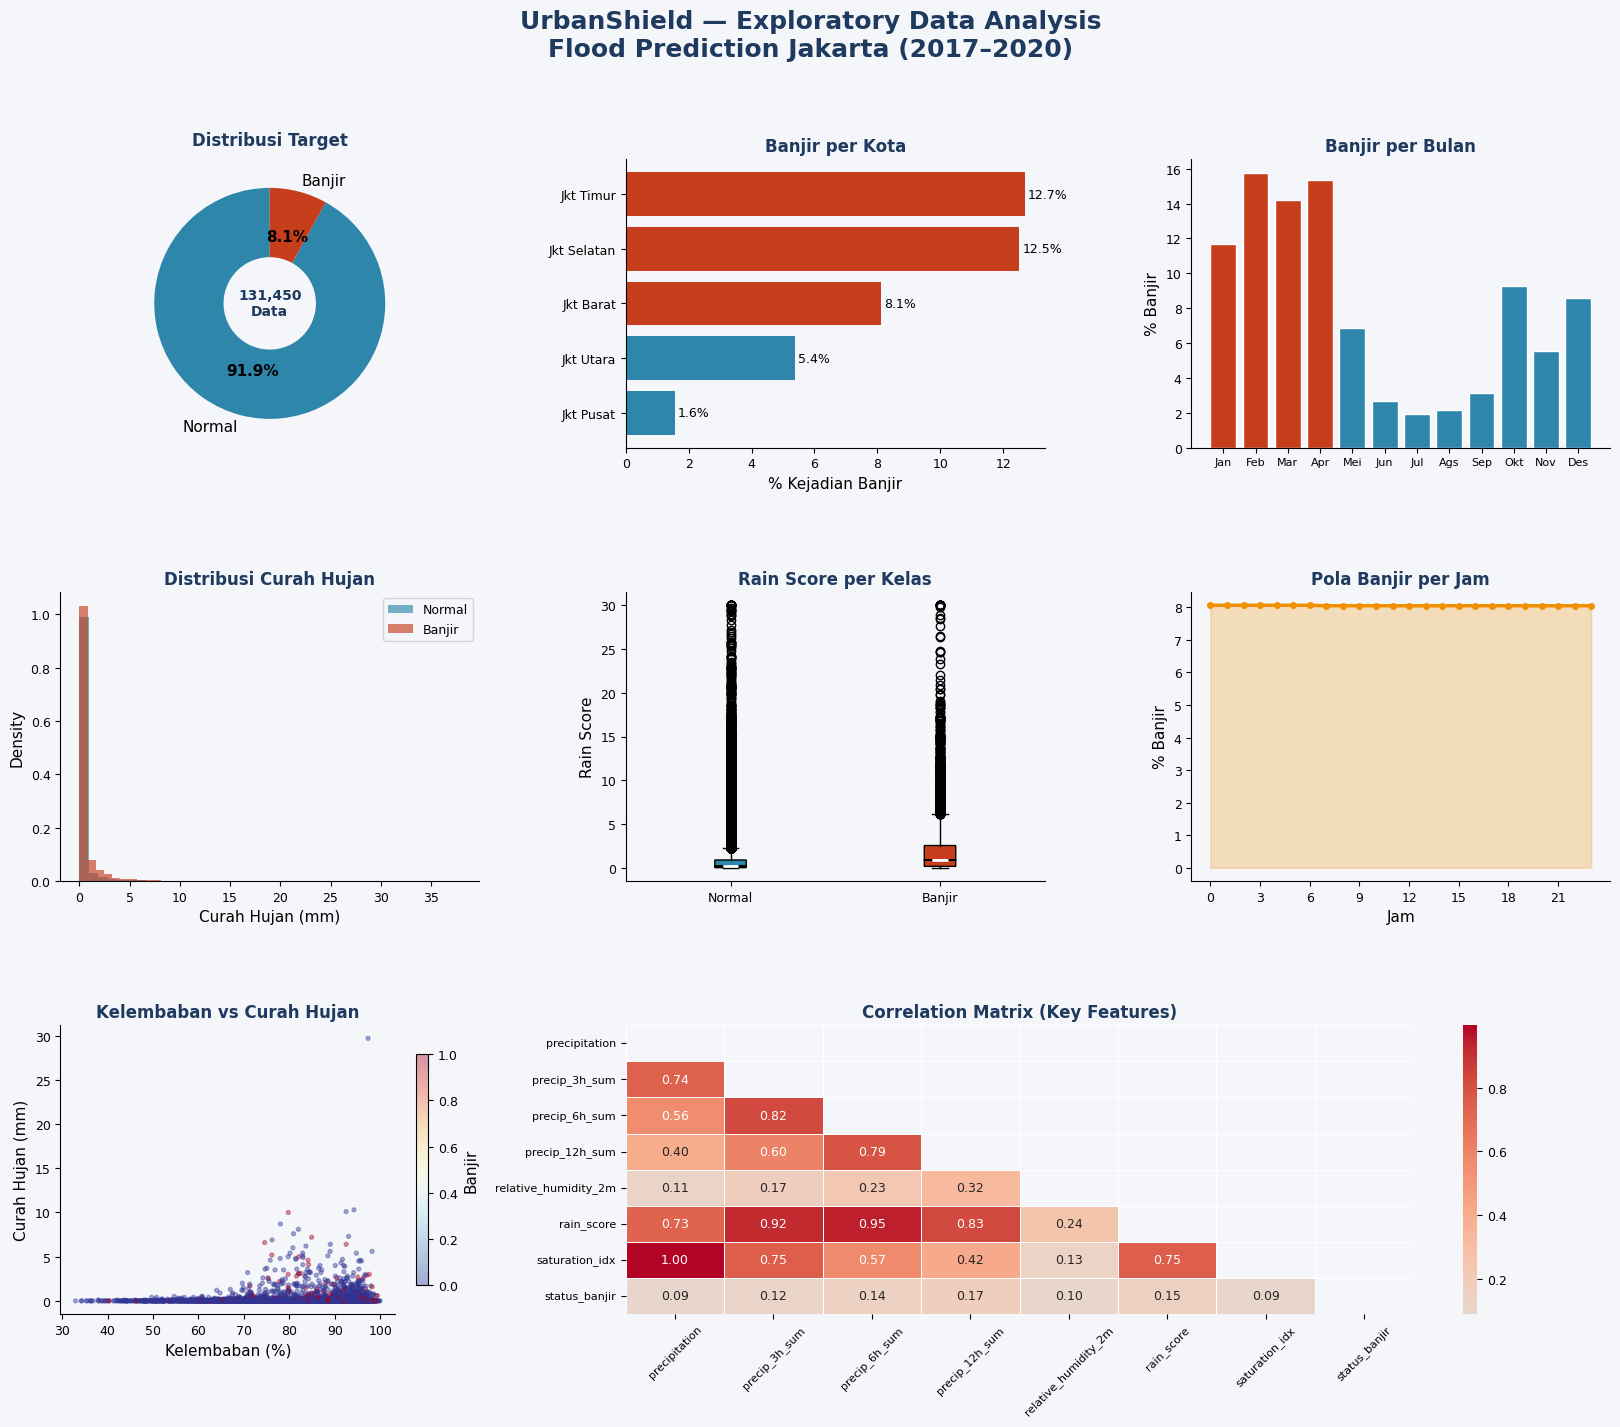

  ✓ EDA selesai & disimpan di folder ./visuals/


In [5]:
print("  STEP 4 — EDA VISUALISASI")

fig = plt.figure(figsize=(20, 15), facecolor=COLORS['light'])
fig.suptitle('UrbanShield — Exploratory Data Analysis\nFlood Prediction Jakarta (2017–2020)',
             fontsize=18, fontweight='bold', color=COLORS['primary'])
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# A: Donut target
ax = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax.pie(
    [vc[0], vc[1]], labels=['Normal', 'Banjir'],
    colors=[COLORS['secondary'], COLORS['danger']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.6), textprops={'fontsize': 11}
)
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Distribusi Target', fontweight='bold', color=COLORS['primary'], pad=10)
ax.text(0, 0, f'{len(df):,}\nData', ha='center', va='center',
        fontsize=10, fontweight='bold', color=COLORS['primary'])

# B: Banjir per kota
ax2 = fig.add_subplot(gs[0, 1])
kota_banjir = df.groupby('kota_administrasi')['status_banjir'].mean() * 100
kota_banjir = kota_banjir.sort_values()
kota_labels = [k.replace('jakarta ', 'Jkt ').title() for k in kota_banjir.index]
c_b = [COLORS['danger'] if v > 8 else COLORS['secondary'] for v in kota_banjir.values]
bars = ax2.barh(kota_labels, kota_banjir.values, color=c_b)
for bar, val in zip(bars, kota_banjir.values):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
ax2.set_xlabel('% Kejadian Banjir')
ax2.set_title('Banjir per Kota', fontweight='bold', color=COLORS['primary'])

# C: Banjir per bulan
ax3 = fig.add_subplot(gs[0, 2])
month_banjir = df.groupby('month')['status_banjir'].mean() * 100
month_names  = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
c_m = [COLORS['danger'] if v > 10 else COLORS['secondary'] for v in month_banjir.values]
ax3.bar(month_names, month_banjir.values, color=c_m, edgecolor='white')
ax3.set_ylabel('% Banjir')
ax3.set_title('Banjir per Bulan', fontweight='bold', color=COLORS['primary'])
ax3.tick_params(axis='x', labelsize=8)

# D: Distribusi curah hujan
ax4 = fig.add_subplot(gs[1, 0])
for label, color, name in [(0, COLORS['secondary'], 'Normal'), (1, COLORS['danger'], 'Banjir')]:
    subset = df[df['status_banjir'] == label]['precipitation'].clip(upper=40)
    ax4.hist(subset, bins=40, alpha=0.65, color=color, label=name, density=True)
ax4.set_xlabel('Curah Hujan (mm)'); ax4.set_ylabel('Density')
ax4.set_title('Distribusi Curah Hujan', fontweight='bold', color=COLORS['primary'])
ax4.legend(fontsize=9)

# E: Boxplot rain_score
ax5 = fig.add_subplot(gs[1, 1])
data_box = [
    df[df['status_banjir'] == 0]['rain_score'].clip(upper=30).values,
    df[df['status_banjir'] == 1]['rain_score'].clip(upper=30).values,
]
bp = ax5.boxplot(data_box, labels=['Normal', 'Banjir'], patch_artist=True, notch=True,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['secondary'])
bp['boxes'][1].set_facecolor(COLORS['danger'])
ax5.set_ylabel('Rain Score')
ax5.set_title('Rain Score per Kelas', fontweight='bold', color=COLORS['primary'])

# F: Pola banjir per jam
ax6 = fig.add_subplot(gs[1, 2])
hour_banjir = df.groupby('hour')['status_banjir'].mean() * 100
ax6.plot(hour_banjir.index, hour_banjir.values,
         color=COLORS['accent'], linewidth=2.5, marker='o', markersize=4)
ax6.fill_between(hour_banjir.index, hour_banjir.values, alpha=0.25, color=COLORS['accent'])
ax6.set_xlabel('Jam'); ax6.set_ylabel('% Banjir')
ax6.set_title('Pola Banjir per Jam', fontweight='bold', color=COLORS['primary'])
ax6.set_xticks(range(0, 24, 3))

# G: Scatter kelembaban vs curah hujan
ax7 = fig.add_subplot(gs[2, 0])
sample = df.sample(4000, random_state=RANDOM_SEED)
sc = ax7.scatter(sample['relative_humidity_2m'],
                 sample['precipitation'].clip(upper=30),
                 c=sample['status_banjir'], cmap='RdYlBu_r', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax7, shrink=0.8, label='Banjir')
ax7.set_xlabel('Kelembaban (%)'); ax7.set_ylabel('Curah Hujan (mm)')
ax7.set_title('Kelembaban vs Curah Hujan', fontweight='bold', color=COLORS['primary'])

# H: Correlation heatmap
ax8 = fig.add_subplot(gs[2, 1:])
key_cols = ['precipitation', 'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum',
            'relative_humidity_2m', 'rain_score', 'saturation_idx', 'status_banjir']
corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax8, annot_kws={'size': 9}, linewidths=0.5)
ax8.set_title('Correlation Matrix (Key Features)', fontweight='bold', color=COLORS['primary'])
ax8.tick_params(axis='x', labelsize=8, rotation=45)
ax8.tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(VISUAL_DIR + '1_eda_overview.png', dpi=130)
plt.show()
print(f"  ✓ EDA selesai & disimpan di folder {VISUAL_DIR}")

## 🧠 Chapter 7: Nowcasting Model Development (Step 5)
Melatih model XGBoost, LightGBM, dan Random Forest untuk prediksi banjir saat ini.

In [6]:
print("  STEP 5 — MODEL NOWCASTING")

X_now = df[FEATURE_COLS_NOW]
y_now = df['status_banjir']

X_train_now, X_test_now, y_train_now, y_test_now = train_test_split(
    X_now, y_now, test_size=0.2, stratify=y_now, random_state=RANDOM_SEED
)
print(f"  Train: {len(X_train_now):,} | Test: {len(X_test_now):,}")

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_now, y_train_now)
print(f"  Setelah SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

spw_now = (y_train_now == 0).sum() / (y_train_now == 1).sum()

nowcast_models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw_now,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=8,
        num_leaves=63, min_child_samples=20,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=10,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    ),
}

nowcast_results = {}
print(f"\n  {'Model':<15} {'CV AUC':>10} {'Test AUC':>10} {'F1 Banjir':>11} {'Accuracy':>10}")
print("  " + "─" * 58)

for name, model in nowcast_models.items():
    Xtr = X_train_now if name == 'XGBoost' else X_train_sm
    ytr = y_train_now if name == 'XGBoost' else y_train_sm

    cv_auc = cross_val_score(model, Xtr, ytr, cv=3, scoring='roc_auc', n_jobs=-1)
    model.fit(Xtr, ytr)

    y_prob = model.predict_proba(X_test_now)[:, 1]
    y_pred = model.predict(X_test_now)

    prec_c, rec_c, thrs = precision_recall_curve(y_test_now, y_prob)
    f1s    = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
    thresh = thrs[np.argmax(f1s)]
    y_opt  = (y_prob >= thresh).astype(int)

    auc = roc_auc_score(y_test_now, y_prob)
    f1  = f1_score(y_test_now, y_opt, pos_label=1)
    acc = accuracy_score(y_test_now, y_opt)

    nowcast_results[name] = {
        'model': model, 'y_prob': y_prob, 'y_pred': y_opt,
        'cv_mean': cv_auc.mean(), 'cv_std': cv_auc.std(),
        'auc': auc, 'f1': f1, 'acc': acc, 'thresh': thresh,
    }
    print(f"  {name:<15} {cv_auc.mean():.4f}±{cv_auc.std():.3f}  "
          f"{auc:.4f}    {f1:.4f}    {acc:.4f}")

best_now_name = max(nowcast_results, key=lambda k: nowcast_results[k]['auc'])
best_now      = nowcast_results[best_now_name]
gap           = abs(best_now['cv_mean'] - best_now['auc'])
print(f"\n  ★ Best Nowcast: {best_now_name}")
print(f"    AUC={best_now['auc']:.4f} | CV={best_now['cv_mean']:.4f} | "
      f"Gap={gap:.4f} {'✓ Tidak Overfit' if gap < 0.02 else '⚠ Cek'}")
print(f"\n{classification_report(y_test_now, best_now['y_pred'], target_names=['Normal','Banjir'])}")

joblib.dump(best_now['model'], OUTPUT_DIR + f'model_nowcast_{best_now_name.lower()}.pkl')
print(f"  ✓ Nowcast model disimpan → model_nowcast_{best_now_name.lower()}.pkl")

  STEP 5 — MODEL NOWCASTING
  Train: 105,160 | Test: 26,290
  Setelah SMOTE: {0: 96693, 1: 96693}

  Model               CV AUC   Test AUC   F1 Banjir   Accuracy
  ──────────────────────────────────────────────────────────
  XGBoost         0.9040±0.001  0.9193    0.5145    0.9048
  LightGBM        0.9837±0.021  0.8883    0.4704    0.8987
  RandomForest    0.9809±0.016  0.8665    0.4341    0.8817

  ★ Best Nowcast: XGBoost
    AUC=0.9193 | CV=0.9040 | Gap=0.0154 ✓ Tidak Overfit

              precision    recall  f1-score   support

      Normal       0.97      0.93      0.95     24173
      Banjir       0.44      0.63      0.51      2117

    accuracy                           0.90     26290
   macro avg       0.70      0.78      0.73     26290
weighted avg       0.92      0.90      0.91     26290

  ✓ Nowcast model disimpan → model_nowcast_xgboost.pkl


## 📈 Chapter 8: Forecasting Features (Step 6)
Menyiapkan fungsi untuk membuat fitur lag dan rolling untuk prediksi masa depan.

In [7]:
def make_forecast_features(df: pd.DataFrame, horizon_h: int) -> pd.DataFrame:
    """
    Buat lag + rolling features untuk prediksi status banjir
    N jam ke depan. Dilakukan PER KOTA agar tidak ada data leakage.

    Parameter:
        df        : DataFrame yang sudah di-sort per kota & datetime
        horizon_h : Berapa jam ke depan yang ingin diprediksi

    Fitur yang dibuat:
        - LAG 1/3/6/12 jam  : nilai cuaca & hujan di masa lalu
        - ROLLING 3/6/12 jam: statistik (mean/max/std) historis hujan
        - Trend hujan        : apakah hujan makin deras atau mereda
        - Streak hujan       : berapa jam berturut-turut hujan
    """
    rain_cols    = ['precipitation', 'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum']
    weather_cols = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure',
                    'wind_speed_10m', 'soil_temperature_0_to_7cm', 'weather_code']

    dfs = []
    for kota, grp in df.groupby('kota_administrasi'):
        grp = grp.copy().sort_values('datetime').reset_index(drop=True)

        grp[f'target_{horizon_h}h'] = grp['status_banjir'].shift(-horizon_h)

        for col in rain_cols + ['status_banjir']:
            for lag in [1, 3, 6, 12]:
                grp[f'{col}_lag{lag}'] = grp[col].shift(lag)

        for col in weather_cols:
            for lag in [1, 3, 6]:
                grp[f'{col}_lag{lag}'] = grp[col].shift(lag)

        for col in rain_cols:
            for win in [3, 6, 12]:
                shifted = grp[col].shift(1)
                grp[f'{col}_roll{win}_mean'] = shifted.rolling(win).mean()
                grp[f'{col}_roll{win}_max']  = shifted.rolling(win).max()
                grp[f'{col}_roll{win}_std']  = shifted.rolling(win).std()

        for col in ['relative_humidity_2m', 'temperature_2m']:
            for win in [3, 6]:
                grp[f'{col}_roll{win}_mean'] = grp[col].shift(1).rolling(win).mean()

        grp['precip_trend_3h']   = grp['precipitation'] - grp['precipitation'].shift(3)
        grp['precip_trend_6h']   = grp['precipitation'] - grp['precipitation'].shift(6)
        grp['rain_acceleration'] = (grp['precip_trend_3h'] -
                                    grp['precipitation'].shift(1).diff(3))

        grp['is_raining']  = (grp['precipitation'] > 0).astype(int)
        grp['consec_rain'] = grp['is_raining'].groupby(
            (grp['is_raining'] != grp['is_raining'].shift()).cumsum()
        ).cumcount()

        grp['rain_score']     = (grp['precipitation'] * 0.4 + grp['precip_3h_sum'] * 0.3 +
                                  grp['precip_6h_sum'] * 0.2 + grp['precip_12h_sum'] * 0.1)
        grp['saturation_idx'] = grp['relative_humidity_2m'] * grp['precipitation'] / 100
        grp['heavy_rain']     = (
            grp['precipitation'] > grp['precipitation'].quantile(0.90)
        ).astype(int)

        dfs.append(grp)

    result = pd.concat(dfs, ignore_index=True)
    result = result.dropna()
    return result

print("  ✓ Fungsi make_forecast_features siap")

  ✓ Fungsi make_forecast_features siap


## 🚀 Chapter 9: Model Forecasting Training (Step 7)
Melatih model untuk horizon +3h, +6h, dan +12h.

In [8]:
print("  STEP 7 — TRAINING FORECAST MODELS (+3h / +6h / +12h)")

EXCLUDE_COLS  = ['datetime', 'tanggal', 'jam', 'kota_administrasi', 'status_banjir']
ALL_TARGETS   = [f'target_{h}h' for h in HORIZONS]

forecast_models  = {}
forecast_results = {}

for H in HORIZONS:
    print(f"\n  {'─'*50}")
    print(f"  Horizon: +{H} Jam ke Depan")
    print(f"  {'─'*50}")

    target_col = f'target_{H}h'
    dfh        = make_forecast_features(df, H)
    print(f"  Rows (setelah dropna): {len(dfh):,}")

    vc_h = dfh[target_col].value_counts()
    print(f"  Target: Normal={vc_h.get(0,0):,} | Banjir={vc_h.get(1,0):,}")

    feat_cols = [c for c in dfh.columns
                 if c not in EXCLUDE_COLS + ALL_TARGETS and dfh[c].dtype != object]

    X = dfh[feat_cols]
    y = dfh[target_col].astype(int)

    split_idx         = int(len(dfh) * 0.8)
    X_train, X_test   = X.iloc[:split_idx],  X.iloc[split_idx:]
    y_train, y_test   = y.iloc[:split_idx],  y.iloc[split_idx:]
    print(f"  Train: {len(X_train):,} | Test: {len(X_test):,}")

    spw = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"  scale_pos_weight: {spw:.1f}")

    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        verbosity=0,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    prec_c, rec_c, thrs = precision_recall_curve(y_test, y_prob)
    f1s        = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
    best_thresh = thrs[np.argmax(f1s)]
    y_pred_opt  = (y_prob >= best_thresh).astype(int)

    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred_opt, pos_label=1)
    acc  = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, pos_label=1)
    rec  = recall_score(y_test, y_pred_opt, pos_label=1)

    print(f"\n  AUC-ROC   : {auc:.4f}")
    print(f"  F1 Banjir : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Threshold : {best_thresh:.3f}")
    print(f"\n{classification_report(y_test, y_pred_opt, target_names=['Normal','Banjir'])}")

    model_path = OUTPUT_DIR + f'model_forecast_{H}h.pkl'
    joblib.dump(model, model_path)
    print(f"  ✓ Disimpan → {model_path}")

    forecast_models[H]  = model
    forecast_results[H] = {
        'model': model, 'feat_cols': feat_cols,
        'y_test': y_test.values, 'y_prob': y_prob, 'y_pred_opt': y_pred_opt,
        'auc': auc, 'f1': f1, 'acc': acc, 'prec': prec, 'rec': rec,
        'thresh': best_thresh,
        'prec_curve': prec_c, 'rec_curve': rec_c, 'thrs': thrs,
        'fi': model.feature_importances_, 'feat_names': feat_cols,
    }

  STEP 7 — TRAINING FORECAST MODELS (+3h / +6h / +12h)

  ──────────────────────────────────────────────────
  Horizon: +3 Jam ke Depan
  ──────────────────────────────────────────────────
  Rows (setelah dropna): 131,375
  Target: Normal=120,791 | Banjir=10,584
  Train: 105,100 | Test: 26,275
  scale_pos_weight: 10.5

  AUC-ROC   : 0.9952
  F1 Banjir : 0.9165
  Precision : 0.9959
  Recall    : 0.8489
  Accuracy  : 0.9917
  Threshold : 0.925

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     24859
      Banjir       1.00      0.85      0.92      1416

    accuracy                           0.99     26275
   macro avg       0.99      0.92      0.96     26275
weighted avg       0.99      0.99      0.99     26275

  ✓ Disimpan → ./model_forecast_3h.pkl

  ──────────────────────────────────────────────────
  Horizon: +6 Jam ke Depan
  ──────────────────────────────────────────────────
  Rows (setelah dropna): 131,360
  Target: Normal=120

## 🏆 Chapter 10: Final Evaluation (Step 8 & 9)
Scorecard akhir dan evaluasi performa.

  STEP 8 — VISUALISASI EVALUASI NOWCASTING


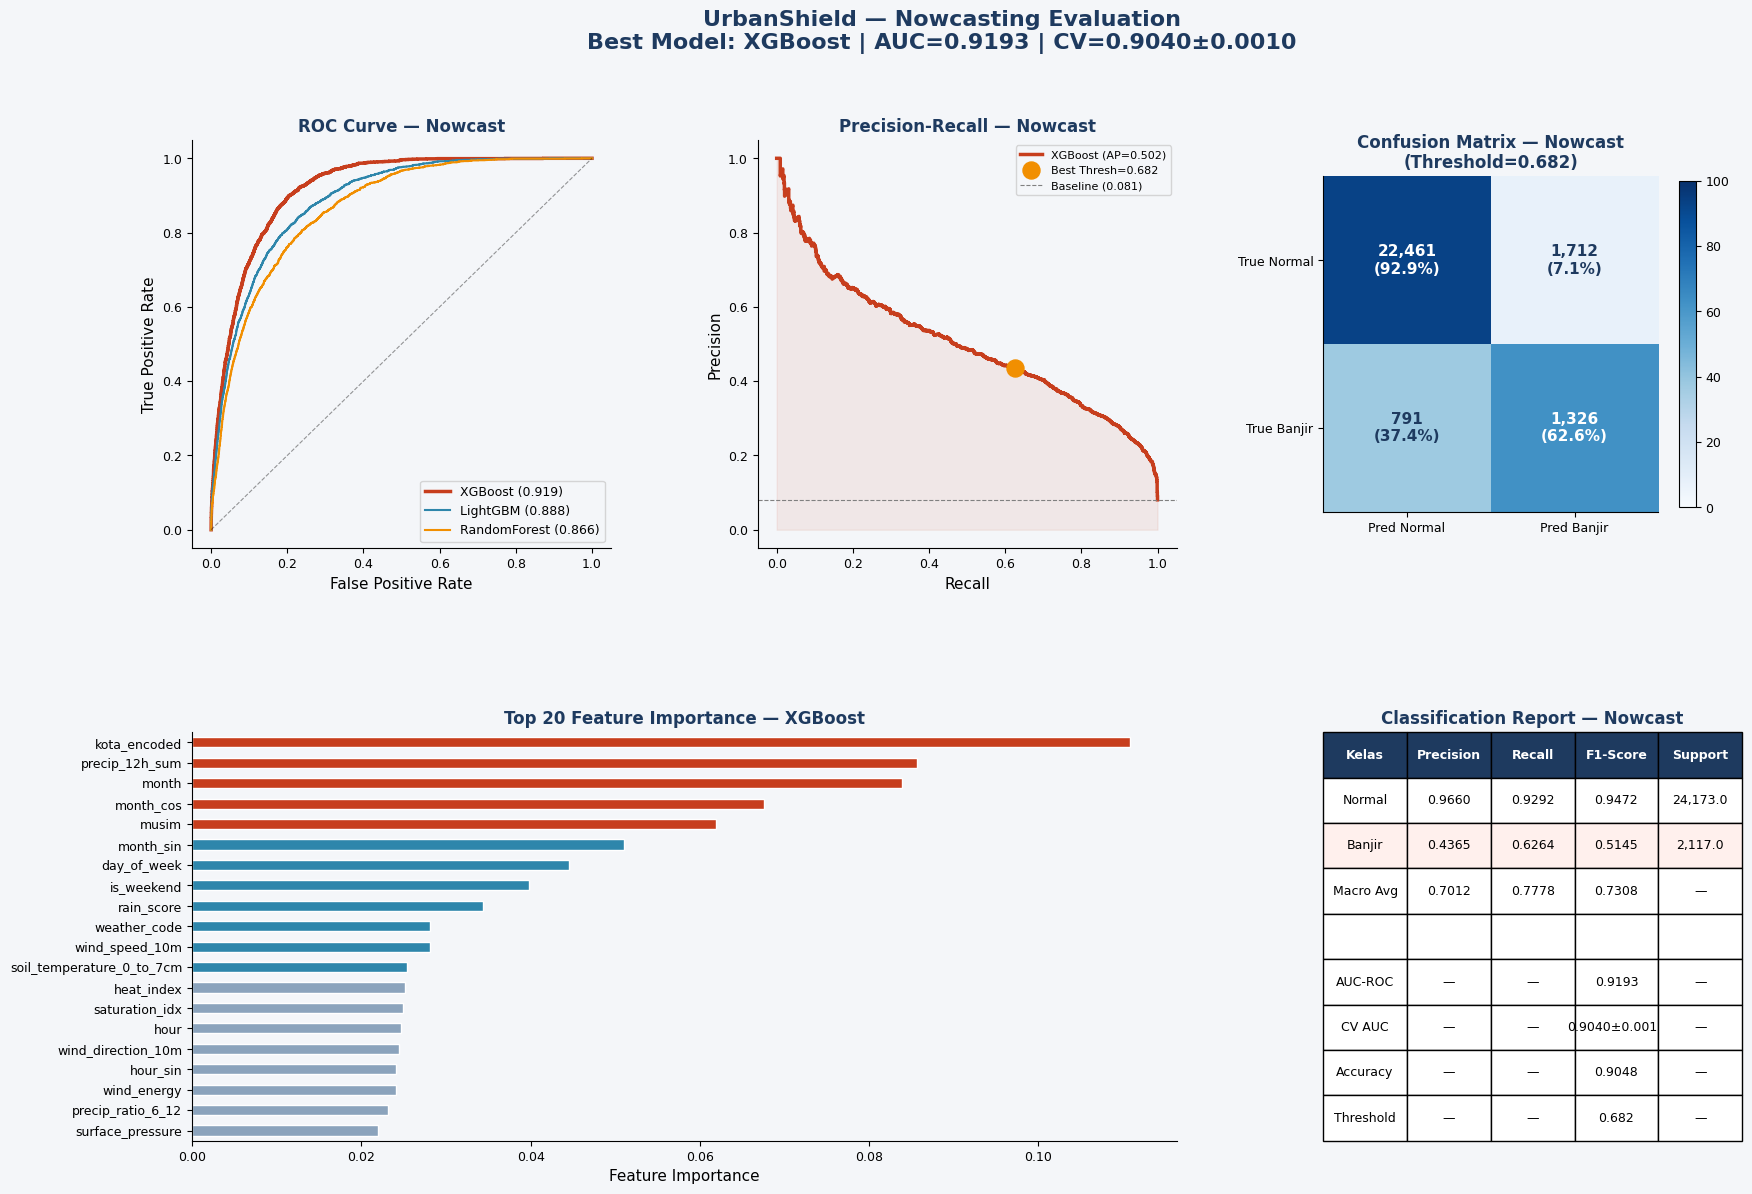

  ✓ Saved → 2_nowcast_evaluation.png


In [9]:
print("  STEP 8 — VISUALISASI EVALUASI NOWCASTING")

fig2 = plt.figure(figsize=(20, 13), facecolor=COLORS['light'])
fig2.suptitle(
    f'UrbanShield — Nowcasting Evaluation\n'
    f'Best Model: {best_now_name} | AUC={best_now["auc"]:.4f} | '
    f'CV={best_now["cv_mean"]:.4f}±{best_now["cv_std"]:.4f}',
    fontsize=16, fontweight='bold', color=COLORS['primary']
)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)

# A: ROC Curve semua model nowcast
ax = fig2.add_subplot(gs2[0, 0])
nc_colors = [COLORS['danger'], COLORS['secondary'], COLORS['accent']]
for (name, res), col in zip(nowcast_results.items(), nc_colors):
    fpr, tpr, _ = roc_curve(y_test_now, res['y_prob'])
    lw = 2.5 if name == best_now_name else 1.5
    ax.plot(fpr, tpr, color=col, linewidth=lw,
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Nowcast', fontweight='bold', color=COLORS['primary'])
ax.legend(fontsize=9)

# B: Precision-Recall Curve
ax2b = fig2.add_subplot(gs2[0, 1])
prec_c, rec_c, thrs_b = precision_recall_curve(y_test_now, best_now['y_prob'])
f1s_b     = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
best_idx  = np.argmax(f1s_b)
ap        = average_precision_score(y_test_now, best_now['y_prob'])
ax2b.plot(rec_c, prec_c, color=COLORS['danger'], linewidth=2.5,
          label=f'{best_now_name} (AP={ap:.3f})')
ax2b.scatter(rec_c[best_idx], prec_c[best_idx],
             color=COLORS['accent'], s=150, zorder=5,
             label=f'Best Thresh={best_now["thresh"]:.3f}')
ax2b.axhline(y_test_now.mean(), color='gray', linestyle='--', linewidth=0.8,
             label=f'Baseline ({y_test_now.mean():.3f})')
ax2b.fill_between(rec_c, prec_c, alpha=0.08, color=COLORS['danger'])
ax2b.set_xlabel('Recall'); ax2b.set_ylabel('Precision')
ax2b.set_title('Precision-Recall — Nowcast', fontweight='bold', color=COLORS['primary'])
ax2b.legend(fontsize=8)

# C: Confusion Matrix nowcast
ax3b = fig2.add_subplot(gs2[0, 2])
cm    = confusion_matrix(y_test_now, best_now['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im = ax3b.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        ax3b.text(j, i, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                  ha='center', va='center', fontsize=11, fontweight='bold',
                  color='white' if cm_pct[i,j] > 55 else COLORS['primary'])
ax3b.set_xticks([0,1]); ax3b.set_yticks([0,1])
ax3b.set_xticklabels(['Pred Normal','Pred Banjir'], fontsize=9)
ax3b.set_yticklabels(['True Normal','True Banjir'], fontsize=9)
ax3b.set_title(f'Confusion Matrix — Nowcast\n(Threshold={best_now["thresh"]:.3f})',
               fontweight='bold', color=COLORS['primary'])
plt.colorbar(im, ax=ax3b, shrink=0.8)

# D: Feature Importance
ax4b = fig2.add_subplot(gs2[1, 0:2])
if hasattr(best_now['model'], 'feature_importances_'):
    fi = pd.Series(best_now['model'].feature_importances_,
                   index=FEATURE_COLS_NOW).nlargest(20)
    c_fi = [COLORS['danger'] if i<5 else COLORS['secondary'] if i<12 else COLORS['mid']
            for i in range(len(fi))]
    fi[::-1].plot(kind='barh', ax=ax4b, color=c_fi[::-1], edgecolor='white')
    ax4b.set_xlabel('Feature Importance')
    ax4b.set_title(f'Top 20 Feature Importance — {best_now_name}',
                   fontweight='bold', color=COLORS['primary'])
    ax4b.tick_params(axis='y', labelsize=9)

# E: Classification Report Table
ax5b = fig2.add_subplot(gs2[1, 2])
ax5b.axis('off')
report = classification_report(y_test_now, best_now['y_pred'],
                               target_names=['Normal','Banjir'], output_dict=True)
tbl_data = [
    ['Kelas',     'Precision', 'Recall', 'F1-Score', 'Support'],
    ['Normal',    f"{report['Normal']['precision']:.4f}",
                  f"{report['Normal']['recall']:.4f}",
                  f"{report['Normal']['f1-score']:.4f}",
                  f"{report['Normal']['support']:,}"],
    ['Banjir',    f"{report['Banjir']['precision']:.4f}",
                  f"{report['Banjir']['recall']:.4f}",
                  f"{report['Banjir']['f1-score']:.4f}",
                  f"{report['Banjir']['support']:,}"],
    ['Macro Avg', f"{report['macro avg']['precision']:.4f}",
                  f"{report['macro avg']['recall']:.4f}",
                  f"{report['macro avg']['f1-score']:.4f}", '—'],
    ['',          '',          '',        '',          ''],
    ['AUC-ROC',   '—', '—', f"{best_now['auc']:.4f}",   '—'],
    ['CV AUC',    '—', '—', f"{best_now['cv_mean']:.4f}±{best_now['cv_std']:.4f}", '—'],
    ['Accuracy',  '—', '—', f"{report['accuracy']:.4f}", '—'],
    ['Threshold', '—', '—', f"{best_now['thresh']:.3f}", '—'],
]
tbl = ax5b.table(cellText=tbl_data[1:], colLabels=tbl_data[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for j in range(5):
    tbl[0, j].set_facecolor(COLORS['primary'])
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for j in range(5):
    tbl[2, j].set_facecolor('#FFF0ED')
ax5b.set_title('Classification Report — Nowcast',
               fontweight='bold', color=COLORS['primary'])

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(VISUAL_DIR + '2_nowcast_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved → 2_nowcast_evaluation.png")


  STEP 9 — VISUALISASI EVALUASI FORECASTING


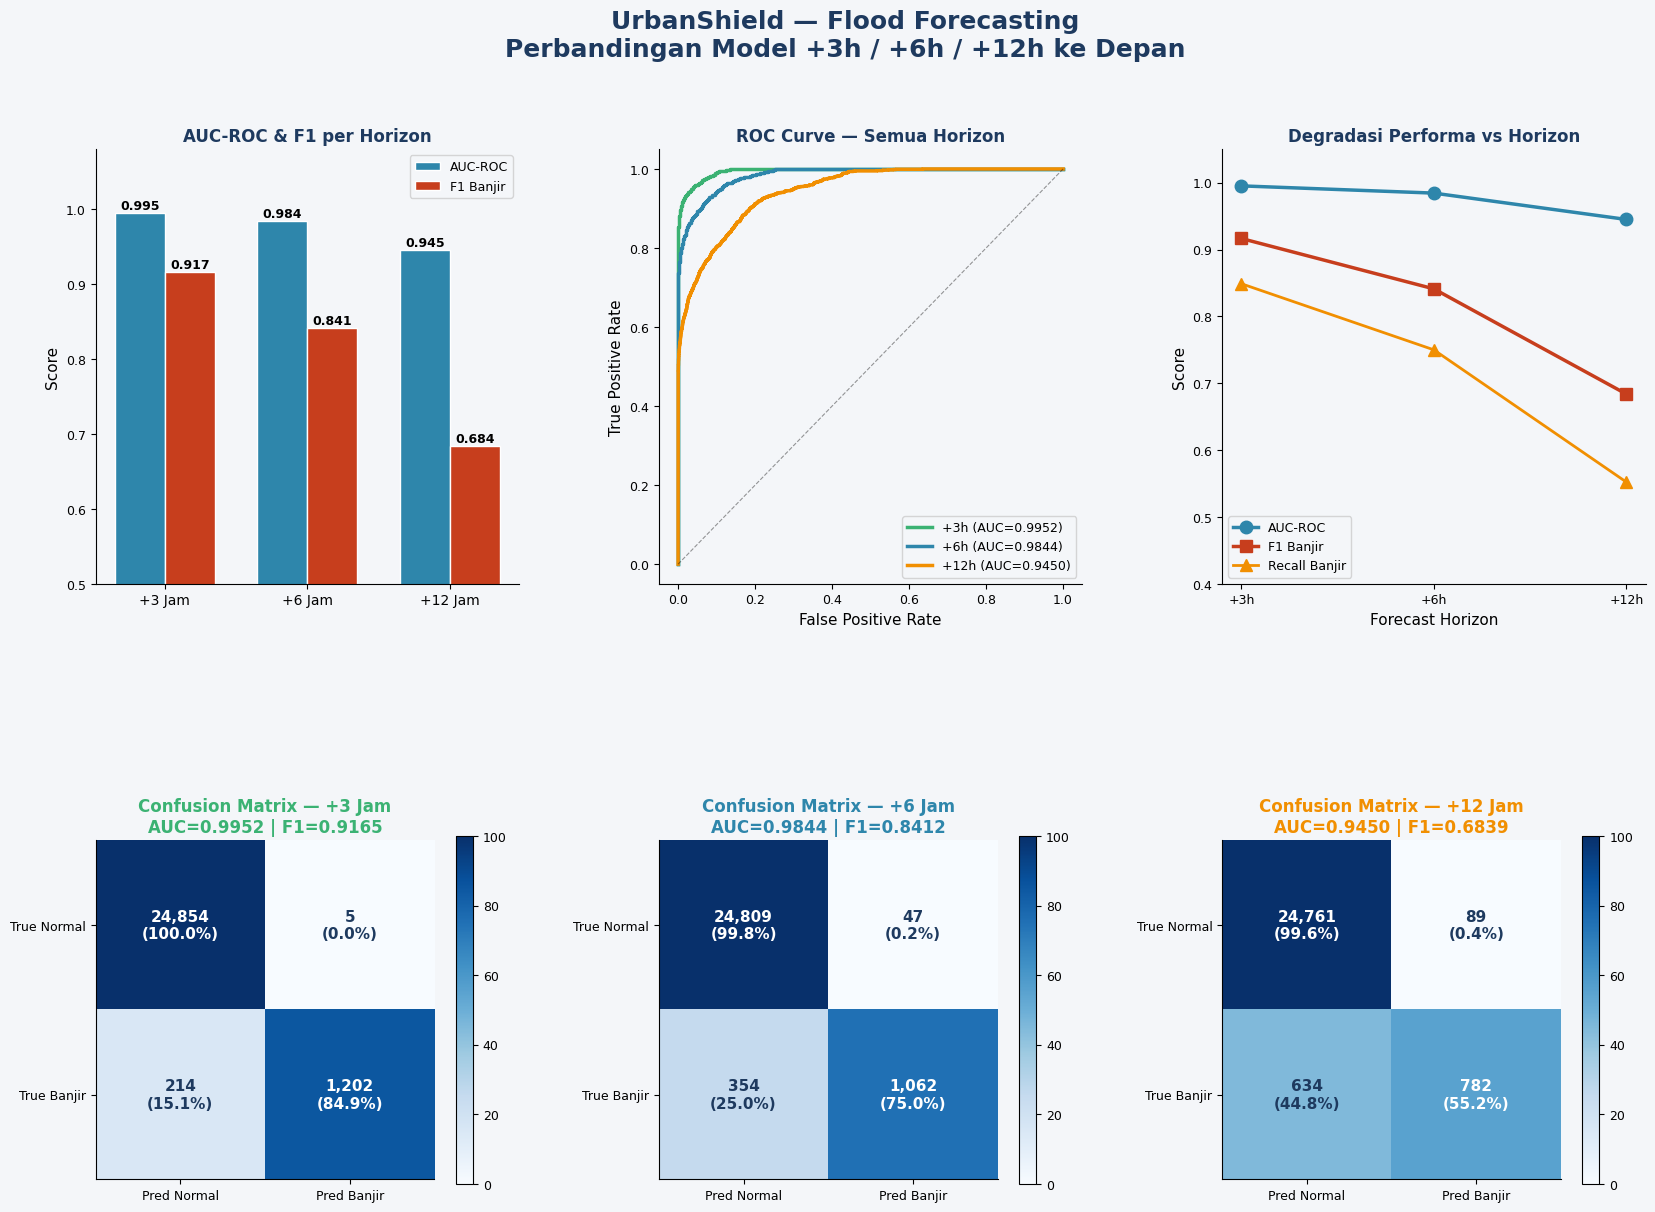

  ✓ Saved → 3_forecast_evaluation.png


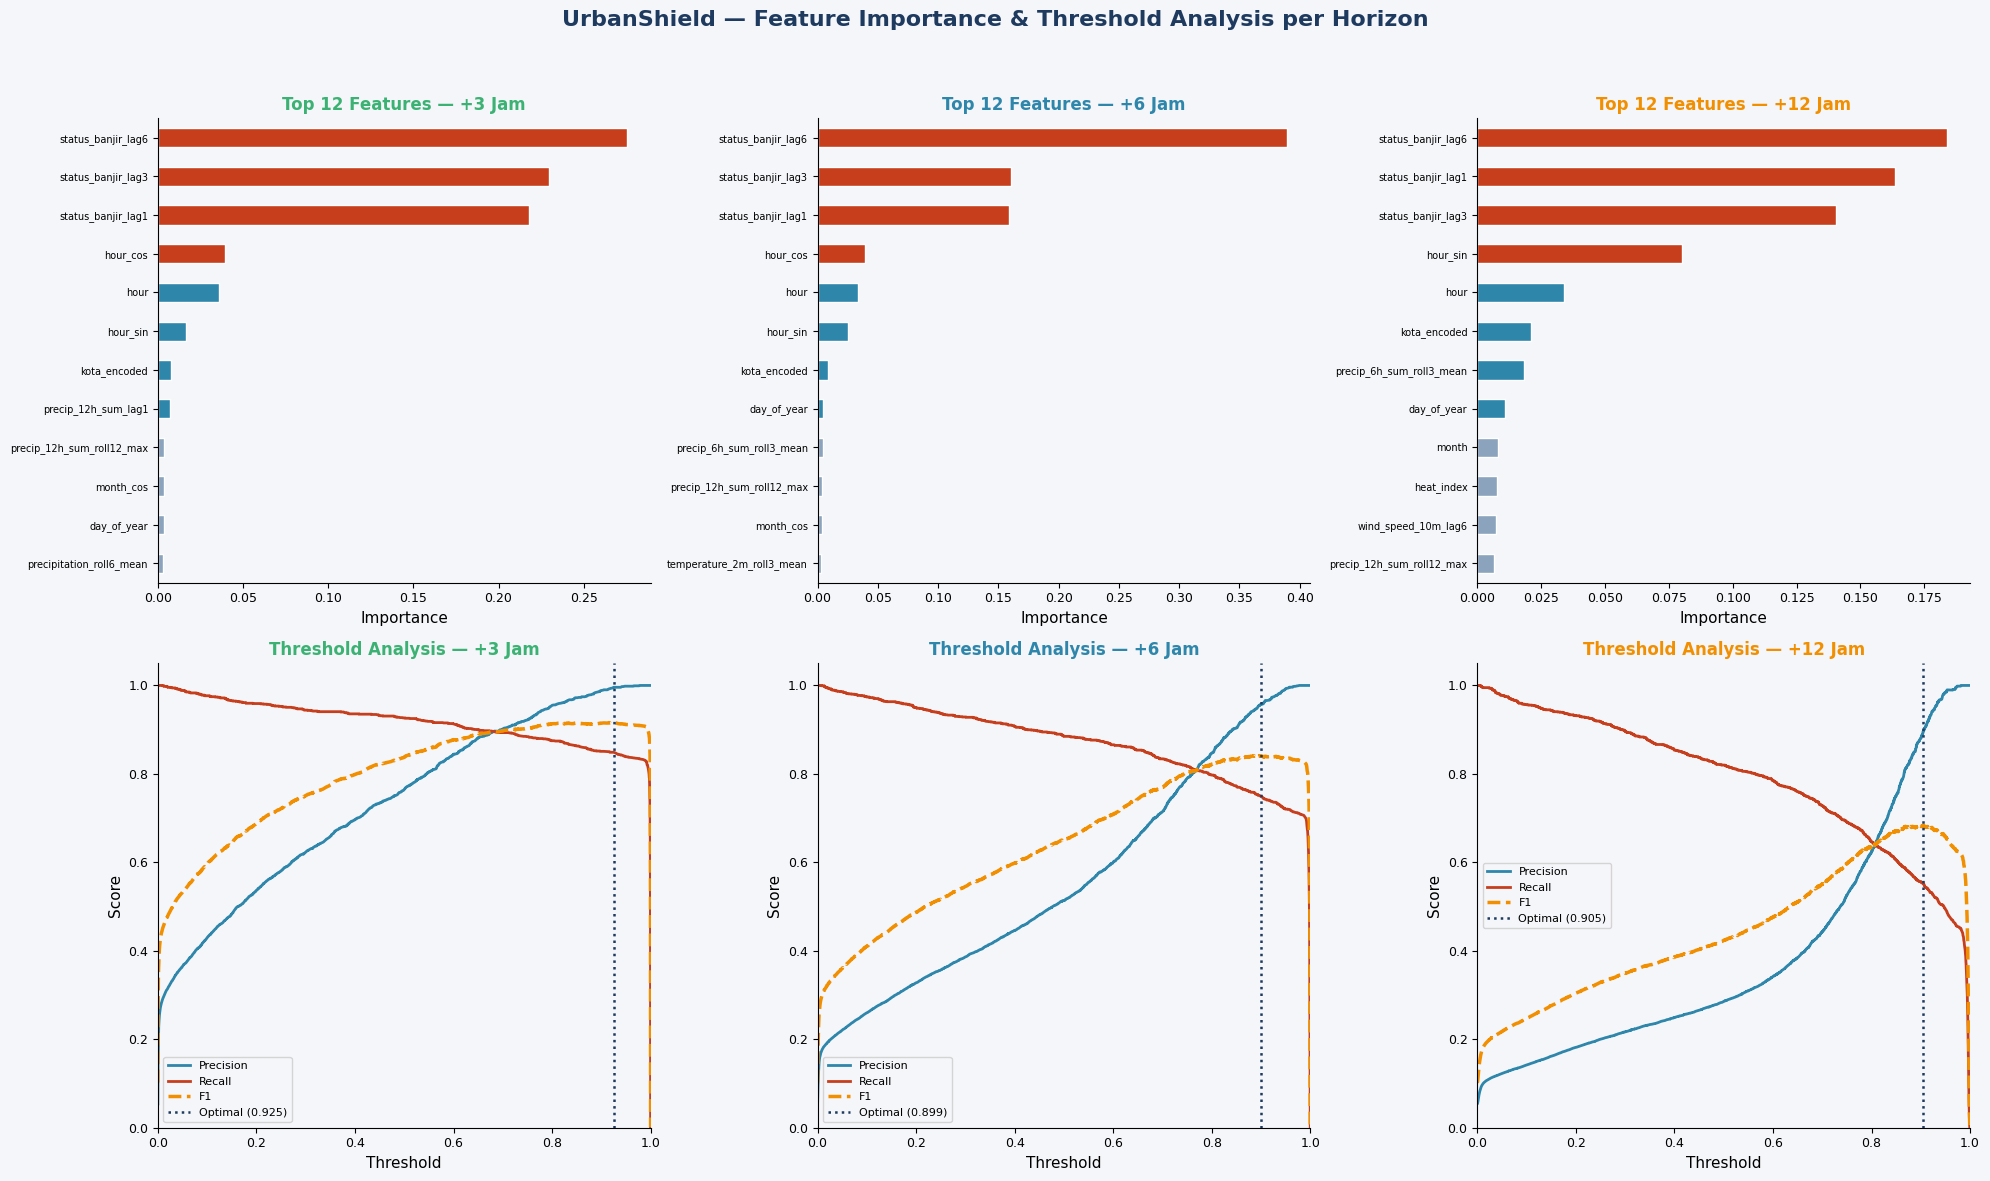

  ✓ Saved → 4_feature_threshold_analysis.png


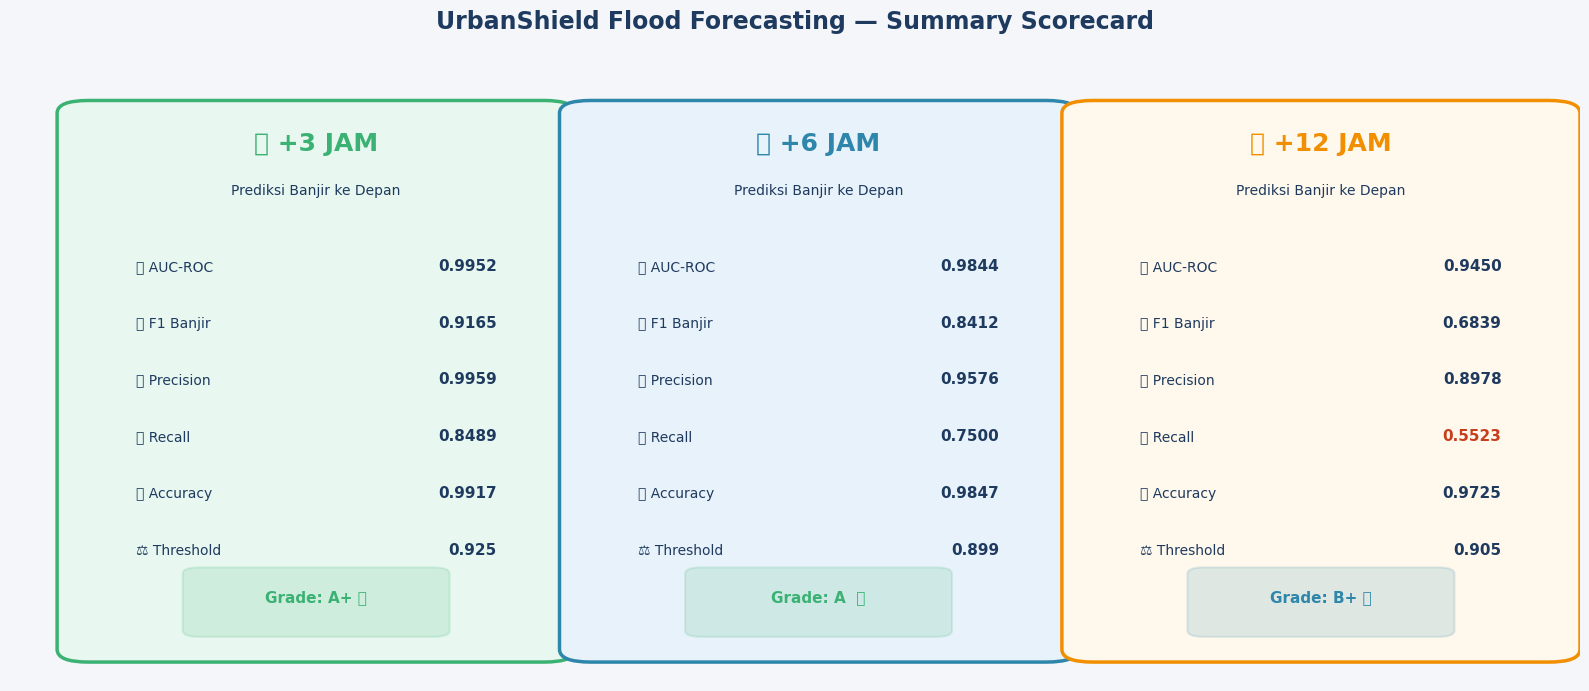

  ✓ Saved → 5_scorecard.png


In [10]:
print("  STEP 9 — VISUALISASI EVALUASI FORECASTING")

fig3 = plt.figure(figsize=(20, 14), facecolor=COLORS['light'])
fig3.suptitle('UrbanShield — Flood Forecasting\nPerbandingan Model +3h / +6h / +12h ke Depan',
              fontsize=18, fontweight='bold', color=COLORS['primary'])
gs3 = gridspec.GridSpec(2, 3, figure=fig3, hspace=0.48, wspace=0.33)

aucs_fc = [forecast_results[h]['auc'] for h in HORIZONS]
f1s_fc  = [forecast_results[h]['f1']  for h in HORIZONS]
recs_fc = [forecast_results[h]['rec'] for h in HORIZONS]

# A: Bar AUC & F1
ax = fig3.add_subplot(gs3[0, 0])
x, w = np.arange(3), 0.35
b1 = ax.bar(x-w/2, aucs_fc, w, label='AUC-ROC',   color=COLORS['secondary'], edgecolor='white')
b2 = ax.bar(x+w/2, f1s_fc,  w, label='F1 Banjir', color=COLORS['danger'],   edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['+3 Jam','+6 Jam','+12 Jam'], fontsize=10)
ax.set_ylim(0.5, 1.08); ax.set_ylabel('Score')
ax.set_title('AUC-ROC & F1 per Horizon', fontweight='bold', color=COLORS['primary'])
ax.legend(fontsize=9)

# B: ROC Curve semua horizon
ax2c = fig3.add_subplot(gs3[0, 1])
for h in HORIZONS:
    fpr, tpr, _ = roc_curve(forecast_results[h]['y_test'], forecast_results[h]['y_prob'])
    ax2c.plot(fpr, tpr, color=HORIZON_COLORS[h], linewidth=2.5,
              label=f'+{h}h (AUC={forecast_results[h]["auc"]:.4f})')
ax2c.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4)
ax2c.set_xlabel('False Positive Rate'); ax2c.set_ylabel('True Positive Rate')
ax2c.set_title('ROC Curve — Semua Horizon', fontweight='bold', color=COLORS['primary'])
ax2c.legend(fontsize=9)

# C: Degradasi performa
ax3c = fig3.add_subplot(gs3[0, 2])
h_labels = ['+3h', '+6h', '+12h']
ax3c.plot(h_labels, aucs_fc, 'o-', color=COLORS['secondary'], lw=2.5, ms=9, label='AUC-ROC')
ax3c.plot(h_labels, f1s_fc,  's-', color=COLORS['danger'],    lw=2.5, ms=9, label='F1 Banjir')
ax3c.plot(h_labels, recs_fc, '^-', color=COLORS['accent'],    lw=2,   ms=9, label='Recall Banjir')
ax3c.set_ylim(0.4, 1.05); ax3c.set_ylabel('Score')
ax3c.set_title('Degradasi Performa vs Horizon', fontweight='bold', color=COLORS['primary'])
ax3c.legend(fontsize=9); ax3c.set_xlabel('Forecast Horizon')

# D, E, F: Confusion Matrix per horizon
for idx, H in enumerate(HORIZONS):
    ax = fig3.add_subplot(gs3[1, idx])
    cm    = confusion_matrix(forecast_results[H]['y_test'], forecast_results[H]['y_pred_opt'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if cm_pct[i,j] > 55 else COLORS['primary'])
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Normal','Pred Banjir'], fontsize=9)
    ax.set_yticklabels(['True Normal','True Banjir'], fontsize=9)
    ax.set_title(f'Confusion Matrix — +{H} Jam\nAUC={forecast_results[H]["auc"]:.4f} '
                 f'| F1={forecast_results[H]["f1"]:.4f}',
                 fontweight='bold', color=HORIZON_COLORS[H])
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(VISUAL_DIR + '3_forecast_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved → 3_forecast_evaluation.png")

# ── Feature importance per horizon ──
fig4, axes4 = plt.subplots(2, 3, figsize=(20, 12), facecolor=COLORS['light'])
fig4.suptitle('UrbanShield — Feature Importance & Threshold Analysis per Horizon',
              fontsize=16, fontweight='bold', color=COLORS['primary'])

for idx, H in enumerate(HORIZONS):
    R = forecast_results[H]

    # Feature importance (top 12)
    ax = axes4[0, idx]
    ax.set_facecolor(COLORS['light'])
    fi = pd.Series(R['fi'], index=R['feat_names']).nlargest(12)
    c_fi = [COLORS['danger'] if i<4 else COLORS['secondary'] if i<8 else COLORS['mid']
            for i in range(len(fi))]
    fi[::-1].plot(kind='barh', ax=ax, color=c_fi[::-1], edgecolor='white')
    ax.set_title(f'Top 12 Features — +{H} Jam', fontweight='bold', color=HORIZON_COLORS[H])
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=7)
    ax.spines[['top','right']].set_visible(False)

    # Threshold analysis
    ax2 = axes4[1, idx]
    ax2.set_facecolor(COLORS['light'])
    f1s_thr = 2*R['prec_curve'][:-1]*R['rec_curve'][:-1]/(R['prec_curve'][:-1]+R['rec_curve'][:-1]+1e-8)
    ax2.plot(R['thrs'], R['prec_curve'][:-1], color=COLORS['secondary'], lw=2, label='Precision')
    ax2.plot(R['thrs'], R['rec_curve'][:-1],  color=COLORS['danger'],    lw=2, label='Recall')
    ax2.plot(R['thrs'], f1s_thr,              color=COLORS['accent'],    lw=2.5, ls='--', label='F1')
    ax2.axvline(R['thresh'], color=COLORS['primary'], lw=1.8, ls=':',
                label=f'Optimal ({R["thresh"]:.3f})')
    ax2.set_xlim(0,1); ax2.set_ylim(0,1.05)
    ax2.set_xlabel('Threshold'); ax2.set_ylabel('Score')
    ax2.set_title(f'Threshold Analysis — +{H} Jam', fontweight='bold', color=HORIZON_COLORS[H])
    ax2.legend(fontsize=8)
    ax2.spines[['top','right']].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig(VISUAL_DIR + '4_feature_threshold_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved → 4_feature_threshold_analysis.png")

# ── Scorecard ──
fig5, ax_sc = plt.subplots(figsize=(16, 7), facecolor=COLORS['light'])
ax_sc.axis('off')
fig5.suptitle('UrbanShield Flood Forecasting — Summary Scorecard',
              fontsize=17, fontweight='bold', color=COLORS['primary'], y=0.98)

h_bg = {3:'#E8F8F0', 6:'#E8F2FA', 12:'#FFF8EC'}
h_hd = {3:COLORS['success'], 6:COLORS['secondary'], 12:COLORS['accent']}

for idx, H in enumerate(HORIZONS):
    R   = forecast_results[H]
    x0  = 0.05 + idx * 0.32
    rect = mpatches.FancyBboxPatch((x0, 0.05), 0.29, 0.85,
                                    boxstyle='round,pad=0.02',
                                    facecolor=h_bg[H], edgecolor=h_hd[H], linewidth=2.5,
                                    transform=ax_sc.transAxes)
    ax_sc.add_patch(rect)
    ax_sc.text(x0+0.145, 0.84, f'⏰ +{H} JAM', ha='center', fontsize=18,
               fontweight='bold', color=h_hd[H], transform=ax_sc.transAxes)
    ax_sc.text(x0+0.145, 0.77, 'Prediksi Banjir ke Depan', ha='center', fontsize=10,
               color=COLORS['primary'], transform=ax_sc.transAxes)

    metrics = [
        ('AUC-ROC',   f"{R['auc']:.4f}",   '🎯'),
        ('F1 Banjir', f"{R['f1']:.4f}",    '🌊'),
        ('Precision', f"{R['prec']:.4f}",  '🔍'),
        ('Recall',    f"{R['rec']:.4f}",   '📡'),
        ('Accuracy',  f"{R['acc']:.4f}",   '✅'),
        ('Threshold', f"{R['thresh']:.3f}",'⚖️'),
    ]
    for mi, (mname, mval, icon) in enumerate(metrics):
        y_pos = 0.65 - mi * 0.09
        ax_sc.text(x0+0.03, y_pos, f'{icon} {mname}', ha='left', fontsize=10,
                   color=COLORS['primary'], transform=ax_sc.transAxes)
        c_val = COLORS['danger'] if mname in ['F1 Banjir','Recall'] and float(mval)<0.6 else COLORS['primary']
        ax_sc.text(x0+0.26, y_pos, mval, ha='right', fontsize=11,
                   fontweight='bold', color=c_val, transform=ax_sc.transAxes)

    auc = R['auc']
    grade, gc = (('A+ 🏆', COLORS['success'])  if auc >= 0.99 else
                 ('A  🥇', COLORS['success'])   if auc >= 0.97 else
                 ('B+ 🥈', COLORS['secondary']) if auc >= 0.93 else
                 ('B  🥉', COLORS['accent']))
    badge = mpatches.FancyBboxPatch((x0+0.07, 0.08), 0.15, 0.09,
                                     boxstyle='round,pad=0.01',
                                     facecolor=gc, alpha=0.15,
                                     edgecolor=gc, linewidth=1.5,
                                     transform=ax_sc.transAxes)
    ax_sc.add_patch(badge)
    ax_sc.text(x0+0.145, 0.125, f'Grade: {grade}', ha='center', fontsize=11,
               fontweight='bold', color=gc, transform=ax_sc.transAxes)

plt.tight_layout()
plt.savefig(VISUAL_DIR + '5_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved → 5_scorecard.png")

In [11]:
print("=" * 65)
print("  RINGKASAN HASIL SEMUA MODEL")
print("=" * 65)
print(f"\n  📌 NOWCASTING (prediksi saat ini)")
print(f"     Model    : {best_now_name}")
print(f"     AUC-ROC  : {best_now['auc']:.4f}")
print(f"     F1 Banjir: {best_now['f1']:.4f}")
print(f"     Accuracy : {best_now['acc']:.4f}")
print(f"     Threshold: {best_now['thresh']:.3f}")

print(f"\n  📌 FORECASTING (prediksi ke depan)")
print(f"  {'Horizon':<12} {'AUC':>8} {'F1 Banjir':>12} {'Recall':>8} {'Accuracy':>10}  {'Grade'}")
print("  " + "─" * 60)
for H in HORIZONS:
    R = forecast_results[H]
    auc = R['auc']
    grade = ('A+ 🏆' if auc>=0.99 else 'A  🥇' if auc>=0.97
             else 'B+ 🥈' if auc>=0.93 else 'B  🥉')
    print(f"  +{H} Jam      {auc:.4f}    {R['f1']:.4f}      {R['rec']:.4f}     {R['acc']:.4f}    {grade}")

print(f"\n  📁 File tersimpan:")
print(f"     model_nowcast_{best_now_name.lower()}.pkl")
for H in HORIZONS:
    print(f"     model_forecast_{H}h.pkl")
print(f"     1_eda_overview.png")
print(f"     2_nowcast_evaluation.png")
print(f"     3_forecast_evaluation.png")
print(f"     4_feature_threshold_analysis.png")
print(f"     5_scorecard.png")
print("\n" + "=" * 65)
print("  SELESAI!")
print("=" * 65)


  RINGKASAN HASIL SEMUA MODEL

  📌 NOWCASTING (prediksi saat ini)
     Model    : XGBoost
     AUC-ROC  : 0.9193
     F1 Banjir: 0.5145
     Accuracy : 0.9048
     Threshold: 0.682

  📌 FORECASTING (prediksi ke depan)
  Horizon           AUC    F1 Banjir   Recall   Accuracy  Grade
  ────────────────────────────────────────────────────────────
  +3 Jam      0.9952    0.9165      0.8489     0.9917    A+ 🏆
  +6 Jam      0.9844    0.8412      0.7500     0.9847    A  🥇
  +12 Jam      0.9450    0.6839      0.5523     0.9725    B+ 🥈

  📁 File tersimpan:
     model_nowcast_xgboost.pkl
     model_forecast_3h.pkl
     model_forecast_6h.pkl
     model_forecast_12h.pkl
     1_eda_overview.png
     2_nowcast_evaluation.png
     3_forecast_evaluation.png
     4_feature_threshold_analysis.png
     5_scorecard.png

  SELESAI!
